# Senator Beck RGB-vs-SW Cloud Classification (Minimal Workflow)

This notebook does only three tasks:
1. Train per-5C-bin RGB decision trees at Senator Beck and evaluate against SW cloud binary.
2. Apply Gothic-derived per-bin RGB thresholds at Senator Beck and evaluate against the same SW cloud binary.
3. Compare per-bin RGB thresholds between Senator Beck-derived and Gothic-derived rules.

In [35]:
def bsrn_hysteresis_cloud_detection(obs_sw, clear_sky_sw, cos_sza, clear_threshold, cloudy_threshold, min_cos_sza):
    """
    Long & Ackerman 2000 cloud detection using clearness index with hysteresis.
    Uses clearness index kt = obs_sw / clear_sky_sw with dual thresholds to reduce noise.
    
    - Clear if: kt > clear_threshold (0.80)
    - Cloudy if: kt < cloudy_threshold (0.70)
    - Ambiguous (0.70–0.80): marked NaN for hysteresis logic
    """
    kt = np.full_like(obs_sw, np.nan, dtype=float)
    valid_clear = clear_sky_sw > 0
    valid_obs = np.isfinite(obs_sw)
    valid_for_ratio = valid_clear & valid_obs
    kt[valid_for_ratio] = obs_sw[valid_for_ratio] / clear_sky_sw[valid_for_ratio]

    cloud_binary = np.full_like(kt, np.nan, dtype=float)
    valid_mask = (cos_sza >= min_cos_sza) & valid_for_ratio

    # Apply thresholds: clear if kt > 0.80, cloudy if kt < 0.70
    cloud_binary[valid_mask & (kt > clear_threshold)] = 0.0
    cloud_binary[valid_mask & (kt < cloudy_threshold)] = 1.0
    # Ambiguous region (0.70 <= kt <= 0.80) left as NaN

    return cloud_binary, kt

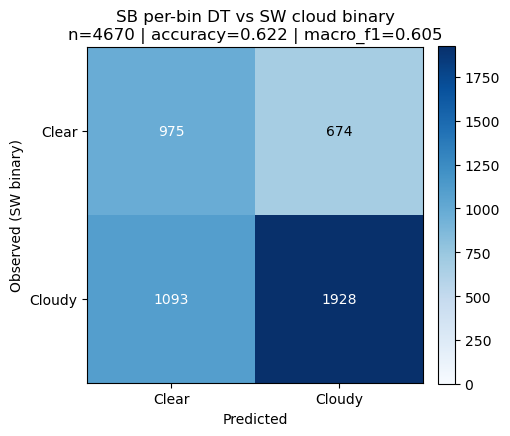

Run 1 confusion matrix:
 [[ 975  674]
 [1093 1928]]
Run 1 accuracy=0.6216, macro_f1=0.6052
Saved Run 1 confusion plot: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_per_bin_dt_confusion_all_timesteps.png
Saved SB threshold table: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_temp_bin_rgb_thresholds_from_dt.csv


,temp_bin,temp_left_c,temp_right_c,n_rows,n_clear,n_cloudy,status,red_threshold,green_threshold,blue_threshold
0,"[-25.0, -20.0)",-25.0,-20.0,17,1,16,skipped_low_sample,NaN,NaN,NaN
1,"[-20.0, -15.0)",-20.0,-15.0,153,25,128,trained,0.672319,0.549608,0.241234
2,"[-15.0, -10.0)",-15.0,-10.0,493,63,430,trained,0.001908,0.447735,0.373927
3,"[-10.0, -5.0)",-10.0,-5.0,830,144,686,trained,0.047846,0.379388,0.383322
4,"[-5.0, 0.0)",-5.0,0.0,816,237,579,trained,0.265076,0.387768,0.242004
5,"[0.0, 5.0)",0.0,5.0,783,315,468,trained,NaN,0.221083,0.295908
6,"[5.0, 10.0)",5.0,10.0,833,391,442,trained,0.124350,0.687272,0.256341
7,"[10.0, 15.0)",10.0,15.0,685,421,264,trained,0.150137,0.173666,0.201252
8,"[15.0, 20.0)",15.0,20.0,77,53,24,trained,NaN,0.243072,0.289129


In [36]:
# -------------------------
# Run 1: SB-derived per-5C-bin RGB decision trees vs SB SW cloud binary
# -------------------------

def extract_tree_thresholds(clf):
    tree = clf.tree_
    feature_names = ['red', 'green', 'blue']
    feature_thresholds = {k: [] for k in feature_names}

    for node_id in range(tree.node_count):
        fid = tree.feature[node_id]
        if fid >= 0:
            fname = feature_names[fid]
            feature_thresholds[fname].append(float(tree.threshold[node_id]))

    # Use median threshold per feature for compact site-vs-site threshold comparison.
    out = {}
    for fname in feature_names:
        vals = feature_thresholds[fname]
        out[f'{fname}_threshold'] = float(np.median(vals)) if vals else np.nan
    return out


def confusion_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'cm': cm,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'clear_f1': float(f1_score(y_true, y_pred, pos_label=0, zero_division=0)),
        'cloudy_f1': float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
    }


sb_pred = pd.Series(index=train_df.index, dtype='float64')
sb_bin_records = []

for temp_bin, grp in train_df.groupby('temp_bin', observed=False):
    if pd.isna(temp_bin):
        continue

    n_rows = len(grp)
    cls = grp['cloud_binary'].value_counts()
    n_clear = int(cls.get(0, 0))
    n_cloudy = int(cls.get(1, 0))

    if n_rows < MIN_ROWS_PER_TEMP_BIN or min(n_clear, n_cloudy) < MIN_CLASS_COUNT_PER_TEMP_BIN:
        sb_bin_records.append({
            'temp_bin': str(temp_bin),
            'temp_left_c': float(temp_bin.left),
            'temp_right_c': float(temp_bin.right),
            'n_rows': n_rows,
            'n_clear': n_clear,
            'n_cloudy': n_cloudy,
            'status': 'skipped_low_sample',
            'red_threshold': np.nan,
            'green_threshold': np.nan,
            'blue_threshold': np.nan,
        })
        continue

    Xb = grp[['red', 'green', 'blue']]
    yb = grp['cloud_binary'].astype(int)

    clf_bin = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=20,
        class_weight='balanced',
        random_state=RNG_SEED,
    )
    clf_bin.fit(Xb, yb)

    yhat = clf_bin.predict(Xb)
    sb_pred.loc[grp.index] = yhat

    th = extract_tree_thresholds(clf_bin)
    sb_bin_records.append({
        'temp_bin': str(temp_bin),
        'temp_left_c': float(temp_bin.left),
        'temp_right_c': float(temp_bin.right),
        'n_rows': n_rows,
        'n_clear': n_clear,
        'n_cloudy': n_cloudy,
        'status': 'trained',
        **th,
    })

sb_eval_df = train_df.loc[sb_pred.notna()].copy()
sb_eval_df['sb_dt_pred'] = sb_pred.loc[sb_eval_df.index].astype(int)

m_sb = confusion_metrics(sb_eval_df['cloud_binary'].to_numpy(), sb_eval_df['sb_dt_pred'].to_numpy())

fig, ax = plt.subplots(figsize=(5.2, 4.8))
im = ax.imshow(m_sb['cm'], cmap='Blues', vmin=0, vmax=max(1, m_sb['cm'].max()))
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Clear', 'Cloudy'])
ax.set_yticklabels(['Clear', 'Cloudy'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed (SW binary)')
ax.set_title(
    'SB per-bin DT vs SW cloud binary\n'
    f"n={len(sb_eval_df)} | accuracy={m_sb['accuracy']:.3f} | macro_f1={m_sb['macro_f1']:.3f}"
)
for r in range(2):
    for c in range(2):
        v = int(m_sb['cm'][r, c])
        ax.text(c, r, f'{v}', ha='center', va='center', color='white' if v > m_sb['cm'].max() / 2 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

sb_conf_png = os.path.join(OUT_DIR, 'sb_per_bin_dt_confusion_all_timesteps.png')
plt.savefig(sb_conf_png, dpi=200, bbox_inches='tight')
plt.show()

sb_bin_thresholds = pd.DataFrame(sb_bin_records).sort_values('temp_left_c').reset_index(drop=True)
sb_bin_thresholds_out = os.path.join(OUT_DIR, 'sb_temp_bin_rgb_thresholds_from_dt.csv')
sb_bin_thresholds.to_csv(sb_bin_thresholds_out, index=False)

print('Run 1 confusion matrix:\n', m_sb['cm'])
print(f"Run 1 accuracy={m_sb['accuracy']:.4f}, macro_f1={m_sb['macro_f1']:.4f}")
print('Saved Run 1 confusion plot:', sb_conf_png)
print('Saved SB threshold table:', sb_bin_thresholds_out)
sb_bin_thresholds

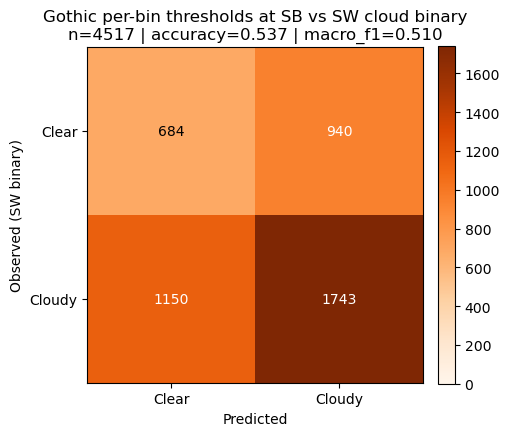

Run 2 confusion matrix:
 [[ 684  940]
 [1150 1743]]
Run 2 accuracy=0.5373, macro_f1=0.5104
Saved Run 2 confusion plot: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_gothic_transfer_confusion_all_timesteps.png
Saved threshold comparison table: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_vs_gothic_temp_bin_threshold_differences.csv


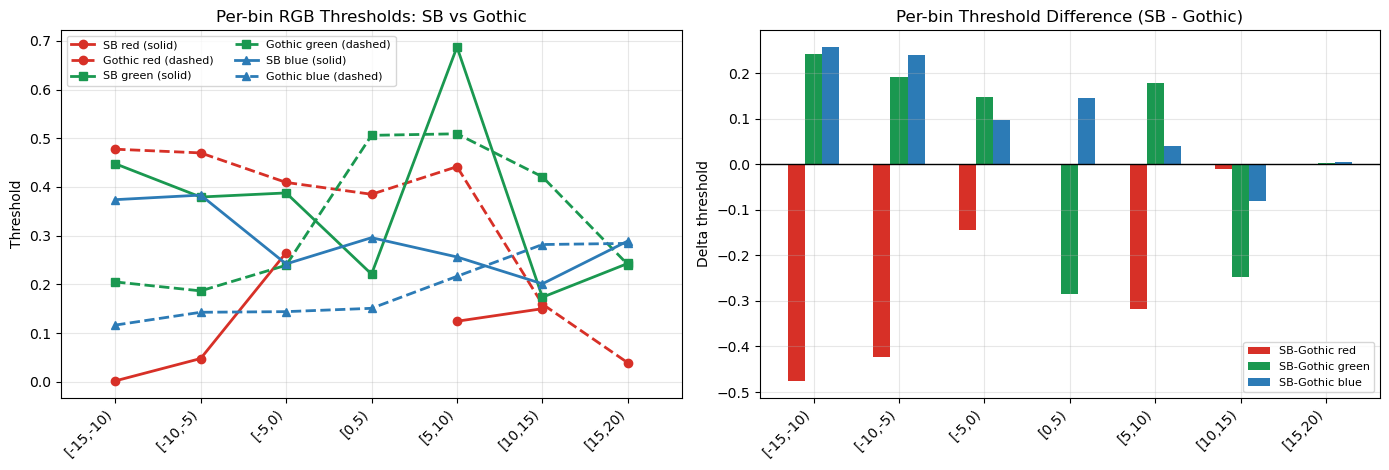

Saved threshold comparison plot: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_vs_gothic_temp_bin_threshold_comparison.png
Saved summary metrics: /glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/sb_vs_gothic_transfer_summary_metrics.csv


,run,n_eval,accuracy,macro_f1
0,SB per-bin DT,4670,0.621627,0.605186
1,Gothic thresholds at SB,4517,0.537304,0.510392


In [37]:
# -------------------------
# Run 2: Apply Gothic-derived per-bin RGB thresholds at SB vs SB SW cloud binary
# -------------------------

gothic_thr = pd.read_csv(GOTHIC_TEMP_BIN_THRESHOLDS_CSV)
required_cols = [
    'temp_left_c', 'temp_right_c', 'status', 'rule',
    'red_threshold', 'red_direction',
    'green_threshold', 'green_direction',
    'blue_threshold', 'blue_direction',
]
missing = [c for c in required_cols if c not in gothic_thr.columns]
if missing:
    raise ValueError(f'Missing columns in Gothic threshold CSV: {missing}')

gothic_thr = gothic_thr[gothic_thr['status'] == 'trained'].copy()

# Build a lookup keyed by bin edge pair
thr_map = {
    (float(r.temp_left_c), float(r.temp_right_c)): r
    for _, r in gothic_thr.iterrows()
}


def cond_for_feature(x, threshold, direction):
    if pd.isna(threshold) or pd.isna(x):
        return False
    if str(direction).strip() == '>':
        return x > threshold
    if str(direction).strip() == '<':
        return x < threshold
    return False


def apply_gothic_row(row):
    key = (float(row['temp_bin'].left), float(row['temp_bin'].right))
    if key not in thr_map:
        return np.nan

    r = thr_map[key]
    c_red = cond_for_feature(row['red'], r.red_threshold, r.red_direction)
    c_green = cond_for_feature(row['green'], r.green_threshold, r.green_direction)
    c_blue = cond_for_feature(row['blue'], r.blue_threshold, r.blue_direction)
    n_true = int(c_red) + int(c_green) + int(c_blue)

    rule = str(r.rule).strip().lower()
    if rule == 'union':
        cloudy = n_true >= 1
    else:
        cloudy = n_true >= 2  # default to majority logic

    return int(cloudy)


gothic_pred = train_df.apply(apply_gothic_row, axis=1)
gothic_eval_df = train_df.loc[gothic_pred.notna()].copy()
gothic_eval_df['gothic_transfer_pred'] = gothic_pred.loc[gothic_eval_df.index].astype(int)

m_g = confusion_metrics(gothic_eval_df['cloud_binary'].to_numpy(), gothic_eval_df['gothic_transfer_pred'].to_numpy())

fig, ax = plt.subplots(figsize=(5.2, 4.8))
im = ax.imshow(m_g['cm'], cmap='Oranges', vmin=0, vmax=max(1, m_g['cm'].max()))
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Clear', 'Cloudy'])
ax.set_yticklabels(['Clear', 'Cloudy'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed (SW binary)')
ax.set_title(
    'Gothic per-bin thresholds at SB vs SW cloud binary\n'
    f"n={len(gothic_eval_df)} | accuracy={m_g['accuracy']:.3f} | macro_f1={m_g['macro_f1']:.3f}"
)
for r in range(2):
    for c in range(2):
        v = int(m_g['cm'][r, c])
        ax.text(c, r, f'{v}', ha='center', va='center', color='white' if v > m_g['cm'].max() / 2 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

gothic_conf_png = os.path.join(OUT_DIR, 'sb_gothic_transfer_confusion_all_timesteps.png')
plt.savefig(gothic_conf_png, dpi=200, bbox_inches='tight')
plt.show()

print('Run 2 confusion matrix:\n', m_g['cm'])
print(f"Run 2 accuracy={m_g['accuracy']:.4f}, macro_f1={m_g['macro_f1']:.4f}")
print('Saved Run 2 confusion plot:', gothic_conf_png)

# -------------------------
# Run 3: Compare per-bin RGB thresholds between SB-derived and Gothic-derived sets
# -------------------------

sb_trained = sb_bin_thresholds[sb_bin_thresholds['status'] == 'trained'].copy()
gothic_trained = gothic_thr.copy()

compare = sb_trained.merge(
    gothic_trained[
        ['temp_left_c', 'temp_right_c', 'red_threshold', 'green_threshold', 'blue_threshold', 'rule']
    ].rename(
        columns={
            'red_threshold': 'gothic_red_threshold',
            'green_threshold': 'gothic_green_threshold',
            'blue_threshold': 'gothic_blue_threshold',
            'rule': 'gothic_rule',
        }
    ),
    on=['temp_left_c', 'temp_right_c'],
    how='inner',
)

compare['d_red'] = compare['red_threshold'] - compare['gothic_red_threshold']
compare['d_green'] = compare['green_threshold'] - compare['gothic_green_threshold']
compare['d_blue'] = compare['blue_threshold'] - compare['gothic_blue_threshold']

compare = compare.sort_values('temp_left_c').reset_index(drop=True)

compare_out = os.path.join(OUT_DIR, 'sb_vs_gothic_temp_bin_threshold_differences.csv')
compare.to_csv(compare_out, index=False)

print('Saved threshold comparison table:', compare_out)
compare[['temp_bin', 'red_threshold', 'gothic_red_threshold', 'd_red',
         'green_threshold', 'gothic_green_threshold', 'd_green',
         'blue_threshold', 'gothic_blue_threshold', 'd_blue', 'gothic_rule']]

# Compact visual comparison
x = np.arange(len(compare))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)

band_colors = {
    'red': '#d73027',
    'green': '#1a9850',
    'blue': '#2c7bb6',
}

# Keep color tied to band; style tied to training run (SB=solid, Gothic=dashed).
axes[0].plot(
    x, compare['red_threshold'], marker='o', linestyle='-', color=band_colors['red'], linewidth=2,
    label='SB red (solid)'
)
axes[0].plot(
    x, compare['gothic_red_threshold'], marker='o', linestyle='--', color=band_colors['red'], linewidth=2,
    label='Gothic red (dashed)'
)
axes[0].plot(
    x, compare['green_threshold'], marker='s', linestyle='-', color=band_colors['green'], linewidth=2,
    label='SB green (solid)'
)
axes[0].plot(
    x, compare['gothic_green_threshold'], marker='s', linestyle='--', color=band_colors['green'], linewidth=2,
    label='Gothic green (dashed)'
)
axes[0].plot(
    x, compare['blue_threshold'], marker='^', linestyle='-', color=band_colors['blue'], linewidth=2,
    label='SB blue (solid)'
)
axes[0].plot(
    x, compare['gothic_blue_threshold'], marker='^', linestyle='--', color=band_colors['blue'], linewidth=2,
    label='Gothic blue (dashed)'
)
axes[0].set_title('Per-bin RGB Thresholds: SB vs Gothic')
axes[0].set_ylabel('Threshold')
axes[0].grid(alpha=0.3)
axes[0].legend(ncol=2, fontsize=8)

axes[1].bar(x - 0.2, compare['d_red'], width=0.2, color=band_colors['red'], label='SB-Gothic red')
axes[1].bar(x, compare['d_green'], width=0.2, color=band_colors['green'], label='SB-Gothic green')
axes[1].bar(x + 0.2, compare['d_blue'], width=0.2, color=band_colors['blue'], label='SB-Gothic blue')
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_title('Per-bin Threshold Difference (SB - Gothic)')
axes[1].set_ylabel('Delta threshold')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

labels = [f"[{l:.0f},{r:.0f})" for l, r in zip(compare['temp_left_c'], compare['temp_right_c'])]
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()
thr_cmp_png = os.path.join(OUT_DIR, 'sb_vs_gothic_temp_bin_threshold_comparison.png')
plt.savefig(thr_cmp_png, dpi=200, bbox_inches='tight')
plt.show()

print('Saved threshold comparison plot:', thr_cmp_png)

summary = pd.DataFrame([
    {'run': 'SB per-bin DT', 'n_eval': len(sb_eval_df), 'accuracy': m_sb['accuracy'], 'macro_f1': m_sb['macro_f1']},
    {'run': 'Gothic thresholds at SB', 'n_eval': len(gothic_eval_df), 'accuracy': m_g['accuracy'], 'macro_f1': m_g['macro_f1']},
])
summary_out = os.path.join(OUT_DIR, 'sb_vs_gothic_transfer_summary_metrics.csv')
summary.to_csv(summary_out, index=False)
print('Saved summary metrics:', summary_out)
summary

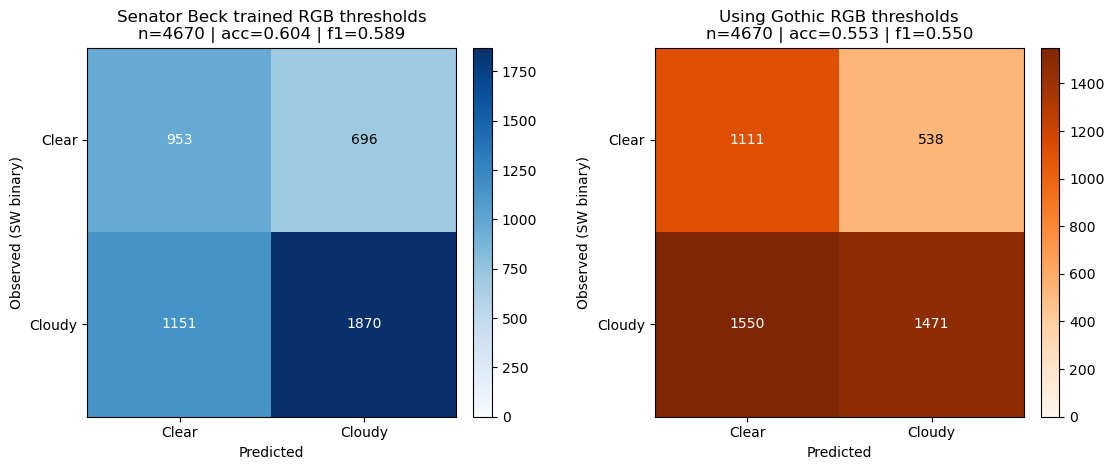

SB retrained 10C confusion:
 [[ 953  696]
 [1151 1870]]
Gothic transfer 10C confusion:
 [[1111  538]
 [1550 1471]]


In [38]:
# Redo both runs with 10C bins (split at 0C): SB retrain vs Gothic transfer
bw = 10.0

def assign_10c_bins_split0(df, temp_col='air_temp_c'):
    d = df.copy()
    tmin = np.floor(min(d[temp_col].min(), 0.0) / bw) * bw
    tmax = np.ceil(max(d[temp_col].max(), 0.0) / bw) * bw
    edges = np.arange(tmin, tmax + bw, bw)
    d['temp_bin_10c'] = pd.cut(d[temp_col], bins=edges, right=False, include_lowest=True)
    return d, edges

def confusion_metrics_local(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    return {
        'cm': cm,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }

def mode_nonnull(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

# Base eval table with 10C bins
base_df, edges10 = assign_10c_bins_split0(train_df, temp_col='air_temp_c')

# --- A) Senator Beck retrained per-10C-bin trees ---
sb_pred_10c = pd.Series(index=base_df.index, dtype='float64')
for tb, grp in base_df.groupby('temp_bin_10c', observed=False):
    if pd.isna(tb):
        continue
    cls = grp['cloud_binary'].value_counts()
    if len(grp) < MIN_ROWS_PER_TEMP_BIN or cls.min() < MIN_CLASS_COUNT_PER_TEMP_BIN or cls.size < 2:
        continue
    clf = DecisionTreeClassifier(max_depth=3, min_samples_split=20, class_weight='balanced', random_state=RNG_SEED)
    clf.fit(grp[['red', 'green', 'blue']], grp['cloud_binary'].astype(int))
    sb_pred_10c.loc[grp.index] = clf.predict(grp[['red', 'green', 'blue']])

sb_eval_10c = base_df.loc[sb_pred_10c.notna()].copy()
sb_eval_10c['pred'] = sb_pred_10c.loc[sb_eval_10c.index].astype(int)
m_sb_10c = confusion_metrics_local(sb_eval_10c['cloud_binary'].to_numpy(), sb_eval_10c['pred'].to_numpy())

# --- B) Gothic transfer, rebinned from source thresholds to 10C split-at-0 bins ---
g = pd.read_csv(GOTHIC_TEMP_BIN_THRESHOLDS_CSV)
g = g[g['status'] == 'trained'].copy()
g['temp_left_10c'] = np.floor(g['temp_left_c'] / bw) * bw
g['temp_right_10c'] = g['temp_left_10c'] + bw

g10 = (
    g.groupby(['temp_left_10c', 'temp_right_10c'], as_index=False)
     .agg({
         'red_threshold': 'median',
         'green_threshold': 'median',
         'blue_threshold': 'median',
         'red_direction': mode_nonnull,
         'green_direction': mode_nonnull,
         'blue_direction': mode_nonnull,
         'rule': mode_nonnull,
     })
)

thr_map10 = {(float(r.temp_left_10c), float(r.temp_right_10c)): r for _, r in g10.iterrows()}

def cond_for_feature(x, threshold, direction):
    if pd.isna(threshold) or pd.isna(x):
        return False
    d = str(direction).strip()
    if d == '>':
        return x > threshold
    if d == '<':
        return x < threshold
    return False

def gothic_pred_row_10c(row):
    tb = row['temp_bin_10c']
    if pd.isna(tb):
        return np.nan
    key = (float(tb.left), float(tb.right))
    if key not in thr_map10:
        return np.nan
    r = thr_map10[key]
    c_red = cond_for_feature(row['red'], r.red_threshold, r.red_direction)
    c_green = cond_for_feature(row['green'], r.green_threshold, r.green_direction)
    c_blue = cond_for_feature(row['blue'], r.blue_threshold, r.blue_direction)
    n_true = int(c_red) + int(c_green) + int(c_blue)
    rule = str(r.rule).strip().lower()
    cloudy = (n_true >= 1) if rule == 'union' else (n_true >= 2)
    return int(cloudy)

g_pred_10c = base_df.apply(gothic_pred_row_10c, axis=1)
g_eval_10c = base_df.loc[g_pred_10c.notna()].copy()
g_eval_10c['pred'] = g_pred_10c.loc[g_eval_10c.index].astype(int)
m_g_10c = confusion_metrics_local(g_eval_10c['cloud_binary'].to_numpy(), g_eval_10c['pred'].to_numpy())

# --- Plot side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, m, ttl, cmap, n in [
    (axes[0], m_sb_10c, 'Senator Beck trained RGB thresholds', 'Blues', len(sb_eval_10c)),
    (axes[1], m_g_10c, 'Using Gothic RGB thresholds', 'Oranges', len(g_eval_10c)),
]:
    im = ax.imshow(m['cm'], cmap=cmap, vmin=0, vmax=max(1, m['cm'].max()))
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Clear', 'Cloudy']); ax.set_yticklabels(['Clear', 'Cloudy'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Observed (SW binary)')
    ax.set_title(f"{ttl}\nn={n} | acc={m['accuracy']:.3f} | f1={m['macro_f1']:.3f}")
    for r in range(2):
        for c in range(2):
            v = int(m['cm'][r, c])
            ax.text(c, r, f'{v}', ha='center', va='center', color='white' if v > m['cm'].max() / 2 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print('SB retrained 10C confusion:\n', m_sb_10c['cm'])
print('Gothic transfer 10C confusion:\n', m_g_10c['cm'])

SBSP data shape: (127742, 49)
SBSP columns: ['ArrayID', 'Year', 'DOY', 'Hour', 'LoAir_Min_C', 'LoAir_Min_Time', 'LoAir_Max_C', 'LoAir_Max_Time', 'Lo_RH', 'UpWind_PGust_MS', 'UpWind_PGust_Time', 'UpWind_SAvg_MS', 'UpWind_Uavg_MS', 'UpWind_Dir_Uavg', 'UpWind_Dir_StDev', 'LoWind_PGust_MS', 'LoWind_PGust_Time', 'LoWind_SAvg_MS', 'LoWind_Uavg_MS', 'LoWind_Dir_Uavg', 'LoWind_Dir_StDev', 'PyDwn_Unfilt_W', 'PyDwn_Filt_W', 'PyUp_Unfilt_W', 'PyUp_Filt_W', 'PyUp_Shad_W', 'Pyrgeom_W', 'Sno_IR_C', 'Sno_Gd_C', 'Sno_10cm_C', 'Sno_20cm_C', 'Sno_30cm_C', 'Sno_40cm_C', 'Sno_Height_M', 'Sys_Volts', 'Placeholder', 'Soil_Flux_W', 'Soil_Surf_C', 'Soil_10cm_C', 'Soil_20cm_C', 'Soil_25cm_C', 'Soil_VWC', 'UpAir_Min_C', 'UpAir_Min_Time', 'UpAir_Max_C', 'UpAir_Max_Time', 'Up_RH', 'Unnamed: 47', 'time']
SW/Radiation observation columns: ['PyDwn_Unfilt_W', 'PyDwn_Filt_W', 'PyUp_Unfilt_W', 'PyUp_Filt_W', 'PyUp_Shad_W', 'Pyrgeom_W']
2023 data: 8760 rows, date range 2023-01-05 04:00:00 to 2024-04-09 00:00:00


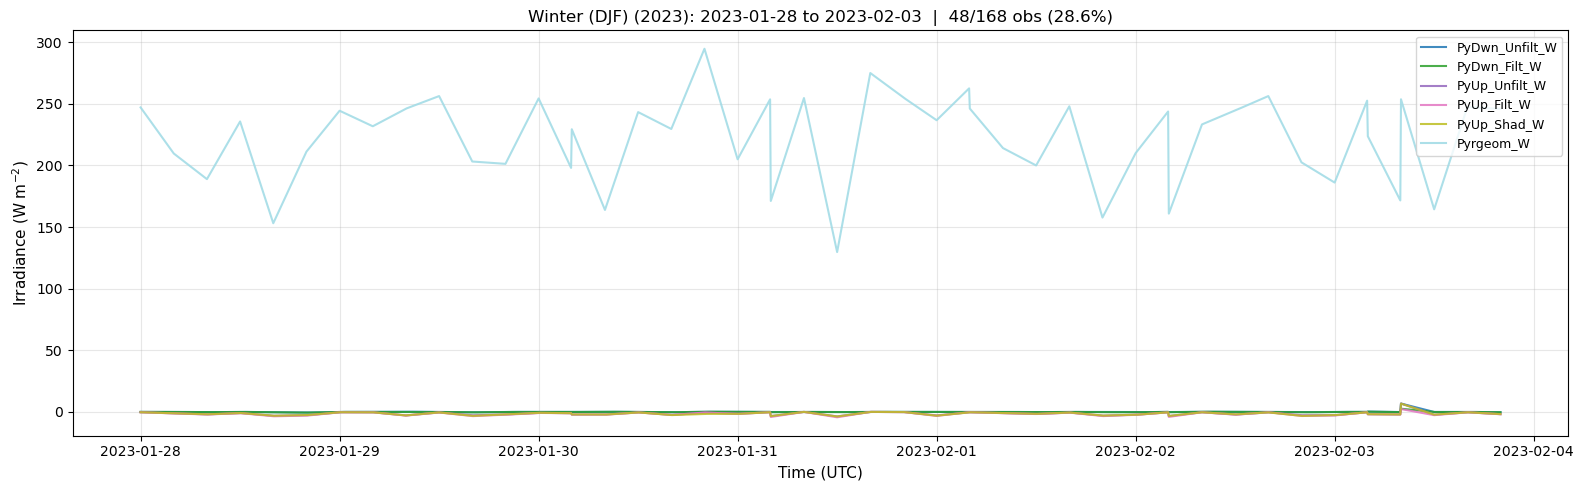


Winter (DJF) table (same 5-min interpolated values used in the time series):


/glade/derecho/scratch/cdalden/tmp/ipykernel_117305/1304476266.py:108: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(season_table.round(2))


,time,PyDwn_Unfilt_W,PyDwn_Filt_W,PyUp_Unfilt_W,PyUp_Filt_W,PyUp_Shad_W,Pyrgeom_W
0,2023-01-28 00:00:00,0.0,0.0,-0.30,-0.30,-0.30,247.10
1,2023-01-28 00:05:00,0.0,0.0,-0.32,-0.32,-0.32,246.32
2,2023-01-28 00:10:00,0.0,0.0,-0.34,-0.34,-0.34,245.54
3,2023-01-28 00:15:00,0.0,0.0,-0.36,-0.36,-0.35,244.76
4,2023-01-28 00:20:00,0.0,0.0,-0.38,-0.38,-0.37,243.98
...,...,...,...,...,...,...,...
2012,2023-02-03 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN
2013,2023-02-03 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2014,2023-02-03 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN
2015,2023-02-03 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN


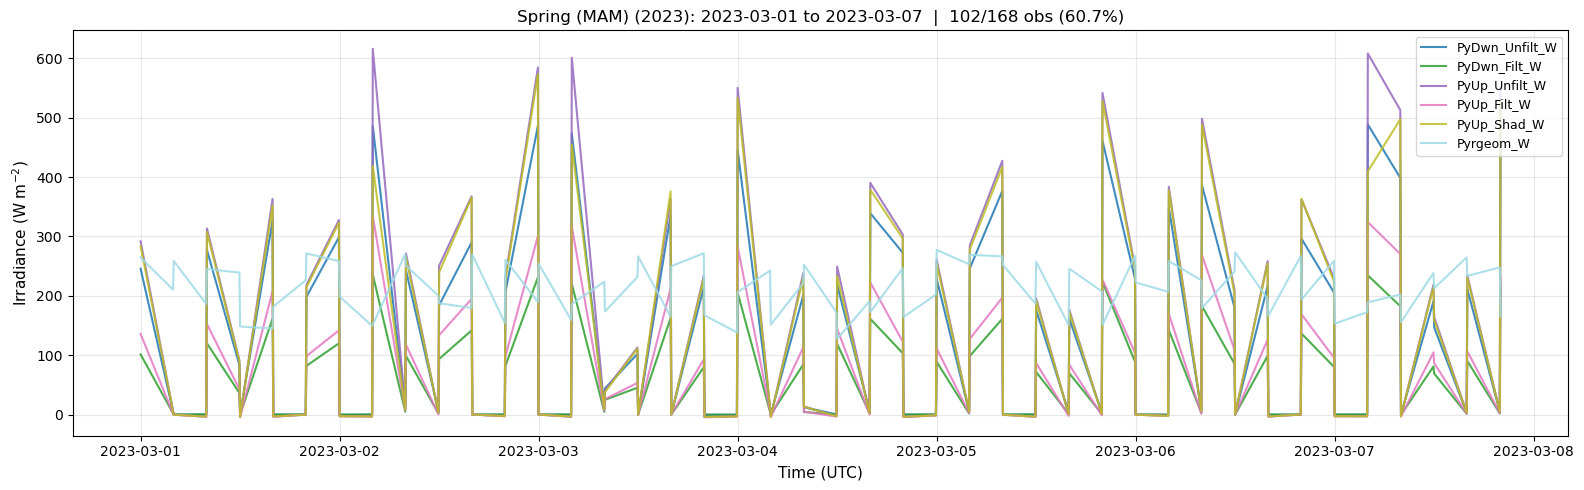


Spring (MAM) table (same 5-min interpolated values used in the time series):


/glade/derecho/scratch/cdalden/tmp/ipykernel_117305/1304476266.py:108: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(season_table.round(2))


,time,PyDwn_Unfilt_W,PyDwn_Filt_W,PyUp_Unfilt_W,PyUp_Filt_W,PyUp_Shad_W,Pyrgeom_W
0,2023-03-01 00:00:00,245.50,101.20,291.60,135.70,283.60,264.50
1,2023-03-01 00:05:00,240.39,99.09,285.50,132.85,277.67,263.35
2,2023-03-01 00:10:00,235.27,96.98,279.41,129.99,271.74,262.20
3,2023-03-01 00:15:00,230.16,94.88,273.31,127.14,265.81,261.05
4,2023-03-01 00:20:00,225.05,92.77,267.22,124.28,259.88,259.90
...,...,...,...,...,...,...,...
2012,2023-03-07 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN
2013,2023-03-07 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2014,2023-03-07 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN
2015,2023-03-07 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN


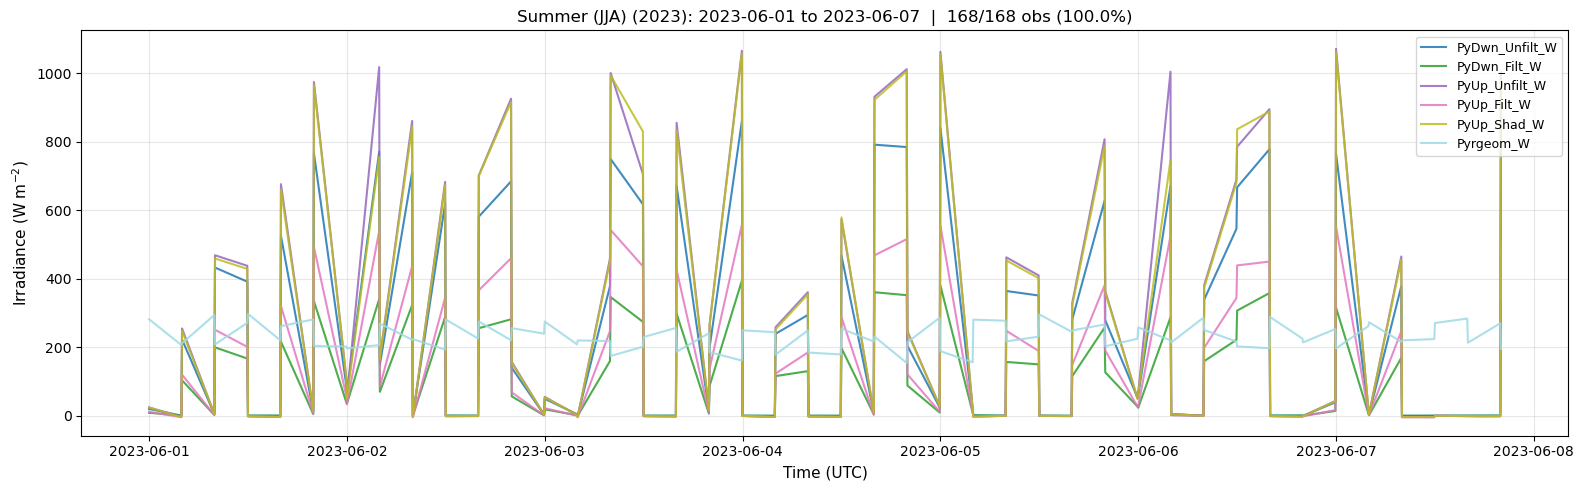


Summer (JJA) table (same 5-min interpolated values used in the time series):


/glade/derecho/scratch/cdalden/tmp/ipykernel_117305/1304476266.py:108: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(season_table.round(2))


,time,PyDwn_Unfilt_W,PyDwn_Filt_W,PyUp_Unfilt_W,PyUp_Filt_W,PyUp_Shad_W,Pyrgeom_W
0,2023-06-01 00:00:00,19.74,8.58,24.32,11.29,23.82,281.60
1,2023-06-01 00:05:00,19.33,8.40,23.73,10.96,23.23,280.00
2,2023-06-01 00:10:00,18.92,8.22,23.13,10.63,22.63,278.40
3,2023-06-01 00:15:00,18.51,8.04,22.54,10.29,22.04,276.79
4,2023-06-01 00:20:00,18.09,7.87,21.94,9.96,21.45,275.19
...,...,...,...,...,...,...,...
2012,2023-06-07 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN
2013,2023-06-07 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2014,2023-06-07 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN
2015,2023-06-07 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN


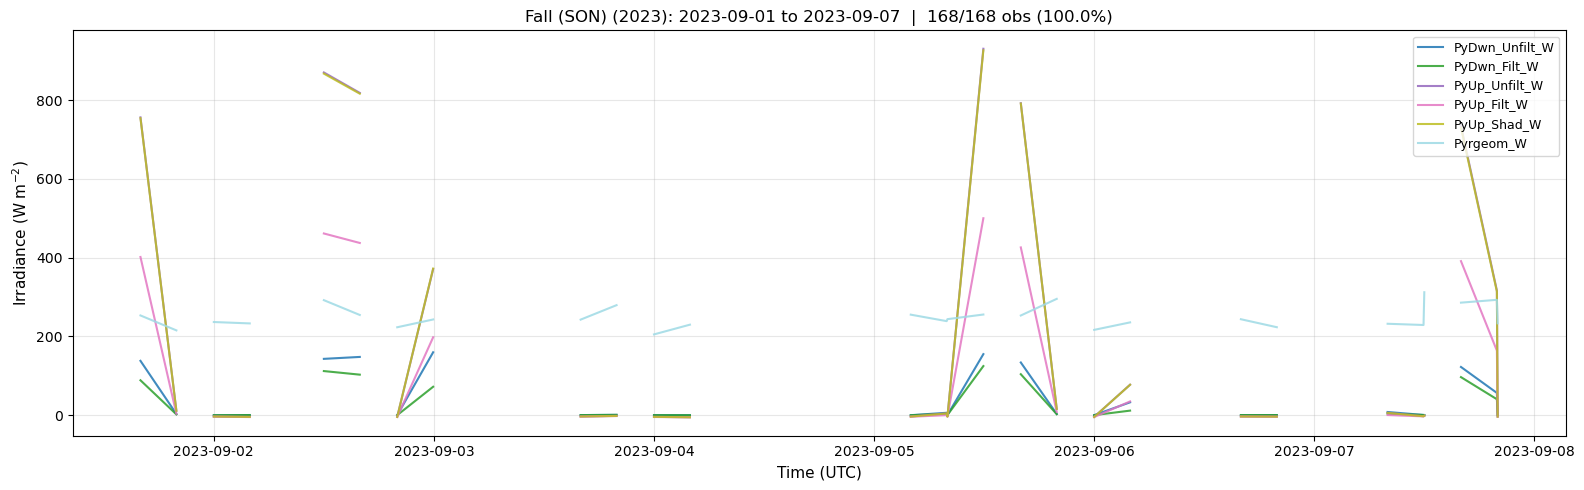


Fall (SON) table (same 5-min interpolated values used in the time series):


/glade/derecho/scratch/cdalden/tmp/ipykernel_117305/1304476266.py:108: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(season_table.round(2))


,time,PyDwn_Unfilt_W,PyDwn_Filt_W,PyUp_Unfilt_W,PyUp_Filt_W,PyUp_Shad_W,Pyrgeom_W
0,2023-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-09-01 00:05:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-09-01 00:10:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-09-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-09-01 00:20:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2012,2023-09-07 23:40:00,NaN,NaN,NaN,NaN,NaN,NaN
2013,2023-09-07 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN
2014,2023-09-07 23:50:00,NaN,NaN,NaN,NaN,NaN,NaN
2015,2023-09-07 23:55:00,NaN,NaN,NaN,NaN,NaN,NaN


{'Winter (DJF)':                     time  PyDwn_Unfilt_W  PyDwn_Filt_W  PyUp_Unfilt_W  \
 0    2023-01-28 00:00:00             0.0      0.005000      -0.304000   
 1    2023-01-28 00:05:00             0.0      0.004875      -0.321833   
 2    2023-01-28 00:10:00             0.0      0.004750      -0.339667   
 3    2023-01-28 00:15:00             0.0      0.004625      -0.357500   
 4    2023-01-28 00:20:00             0.0      0.004500      -0.375333   
 ...                  ...             ...           ...            ...   
 2012 2023-02-03 23:40:00             NaN           NaN            NaN   
 2013 2023-02-03 23:45:00             NaN           NaN            NaN   
 2014 2023-02-03 23:50:00             NaN           NaN            NaN   
 2015 2023-02-03 23:55:00             NaN           NaN            NaN   
 2016 2023-02-04 00:00:00             NaN           NaN            NaN   
 
       PyUp_Filt_W  PyUp_Shad_W   Pyrgeom_W  
 0          -0.295    -0.302000  247.100000  
 1

In [39]:
# SW observations at Senator Beck: one 7-day window per season (2023)
# Load directly from SBSP_1hr file and plot all SW observation columns
from IPython.display import display

sbsp_file = '/glade/u/home/cdalden/goes_work/analysis/SBSP_1hr_2010-2024.csv'
sbsp_data = pd.read_csv(sbsp_file)

# Reconstruct time from Year, DOY (Day of Year), Hour
sbsp_data['time'] = pd.to_datetime(
    sbsp_data['Year'].astype(str) + '-' + sbsp_data['DOY'].astype(str),
    format='%Y-%j'
) + pd.to_timedelta(sbsp_data['Hour'], unit='h')

print(f"SBSP data shape: {sbsp_data.shape}")
print(f"SBSP columns: {sbsp_data.columns.tolist()}")

# Find all SW observation columns (all Py columns are pyranometer measurements)
# Look for columns that contain radiation/irradiance measurements
sw_obs_cols = [c for c in sbsp_data.columns if 'Py' in c or 'py' in c]
print(f"SW/Radiation observation columns: {sw_obs_cols}")

# Filter to 2023 only
sbsp_2023 = sbsp_data[sbsp_data['Year'] == 2023].copy()
sbsp_2023 = sbsp_2023.sort_values('time').reset_index(drop=True)

if sbsp_2023.empty:
    raise ValueError('No 2023 data found in SBSP file')

print(f"2023 data: {len(sbsp_2023)} rows, date range {sbsp_2023['time'].min()} to {sbsp_2023['time'].max()}")

def pick_week_sbsp(df, months, min_points=48):
    cand = df[df['time'].dt.month.isin(months)]
    if cand.empty:
        return None
    for _, row in cand.iterrows():
        t0 = row['time'].floor('D')
        t1 = t0 + pd.Timedelta(days=7)
        w = cand[(cand['time'] >= t0) & (cand['time'] < t1)]
        if len(w) >= min_points:
            return w, t0, t1
    t0 = cand['time'].min().floor('D')
    t1 = t0 + pd.Timedelta(days=7)
    w = cand[(cand['time'] >= t0) & (cand['time'] < t1)]
    return w, t0, t1

seasons = [
    ('Winter (DJF)', [12, 1, 2]),
    ('Spring (MAM)', [3, 4, 5]),
    ('Summer (JJA)', [6, 7, 8]),
    ('Fall (SON)', [9, 10, 11]),
]

# Color map for SW columns
colors = plt.cm.tab20(np.linspace(0, 1, len(sw_obs_cols)))
sw_colors = {col: colors[i] for i, col in enumerate(sw_obs_cols)}

season_tables = {}

for label, months in seasons:
    out = pick_week_sbsp(sbsp_2023, months)
    if out is None:
        print(f"No data for {label}")
        continue

    w, t0, t1 = out
    w = w.sort_values('time').reset_index(drop=True)

    # Analyze data coverage
    n_obs = len(w)
    n_possible_hourly = int((t1 - t0).total_seconds() / 3600)
    coverage_pct = 100 * n_obs / n_possible_hourly

    # Interpolate to 5-min resolution for smooth plotting
    time_5min = pd.date_range(start=t0, end=t1, freq='5min')

    # Build table with the same interpolated values used in the time-series plot
    season_table = pd.DataFrame({'time': time_5min})

    # Create individual large figure for each season
    fig, ax = plt.subplots(figsize=(16, 5))

    # Plot all SW observation columns (interpolated to 5-min for smooth appearance)
    for sw_col in sw_obs_cols:
        if sw_col in w.columns:
            sw_vals = pd.to_numeric(w[sw_col], errors='coerce').values
            sw_5min = np.interp(
                time_5min.astype(np.int64),
                w['time'].astype(np.int64),
                sw_vals,
                left=np.nan, right=np.nan
            )
            season_table[sw_col] = sw_5min
            ax.plot(time_5min, sw_5min, label=sw_col,
                    color=sw_colors[sw_col], linewidth=1.5, linestyle='-', alpha=0.85)

    ax.set_title(f"{label} (2023): {t0.date()} to {(t1 - pd.Timedelta(seconds=1)).date()}  |  {n_obs}/{n_possible_hourly} obs ({coverage_pct:.1f}%)", fontsize=12)
    ax.set_xlabel('Time (UTC)', fontsize=11)
    ax.set_ylabel('Irradiance (W m$^{-2}$)', fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

    season_tables[label] = season_table

    print(f"\n{label} table (same 5-min interpolated values used in the time series):")
    display(season_table.round(2))

# Optional: access any table later, e.g., season_tables['Winter (DJF)'].head()
season_tables

=== SW DATA QUALITY CHECK ===

Negative SW values: 0 (0.00%)
  Min value: 0.00
  Max negative: nan

Exactly zero SW readings: 921 (0.72%)

Near-zero (<= 1 W/m²) during daytime (clear_sky > 50): 884 (1.49%)

Extreme values:
  Max obs_sw: 1341.00
  99th percentile: 1107.00
  95th percentile: 985.00

Bad data distribution by date:
  Dates with bad data: 832
  Max bad records in one day: 5
  First bad date: 2010-01-24
  Last bad date: 2024-07-10


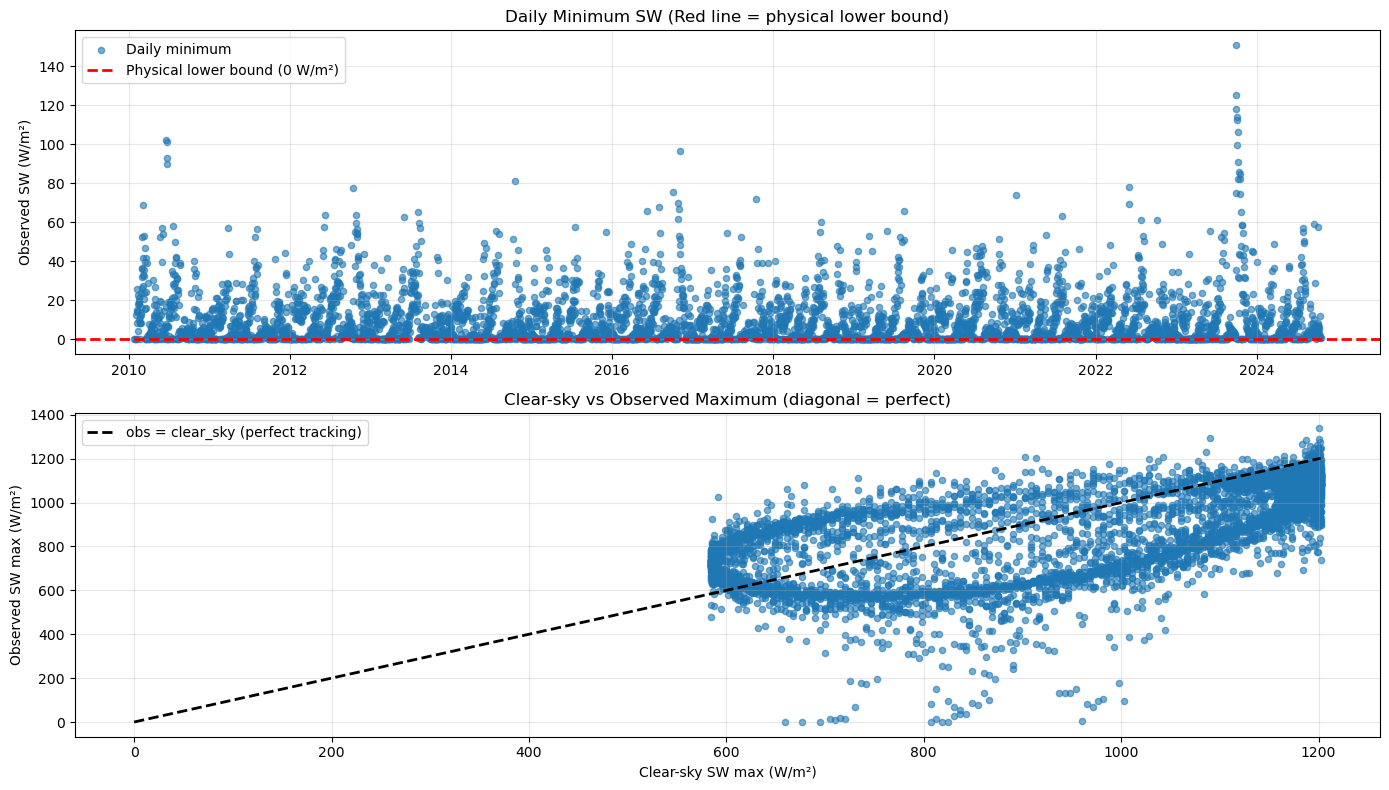


→ Conclusion: The 'spikes to zero' are INSTRUMENT ERRORS, not clouds.
  Negative values & exact zeros are data quality issues, not physical phenomena.


In [40]:
# Diagnostic: Data quality issues - not clouds, but instrument/processing errors
if 'sw' not in globals():
    raise ValueError("'sw' dataframe not found.")

# Check for physical impossibilities: negative, unrealistic SW, or zero readings
print("=== SW DATA QUALITY CHECK ===\n")

# 1. Negative values (physically impossible)
negative_mask = sw['obs_sw'] < 0
print(f"Negative SW values: {negative_mask.sum()} ({100*negative_mask.sum()/len(sw):.2f}%)")
print(f"  Min value: {sw['obs_sw'].min():.2f}")
print(f"  Max negative: {sw[negative_mask]['obs_sw'].max():.2f}")

# 2. Exactly zero readings
zero_mask = sw['obs_sw'] == 0
print(f"\nExactly zero SW readings: {zero_mask.sum()} ({100*zero_mask.sum()/len(sw):.2f}%)")

# 3. Near-zero readings when sun is up (clear_sky > 50)
daytime_mask = sw['clear_sky_sw'] > 50
nearzero_daytime = (sw['obs_sw'] <= 1) & daytime_mask
print(f"\nNear-zero (<= 1 W/m²) during daytime (clear_sky > 50): {nearzero_daytime.sum()} ({100*nearzero_daytime.sum()/daytime_mask.sum():.2f}%)")

# 4. Extreme values
print(f"\nExtreme values:")
print(f"  Max obs_sw: {sw['obs_sw'].max():.2f}")
print(f"  99th percentile: {sw['obs_sw'].quantile(0.99):.2f}")
print(f"  95th percentile: {sw['obs_sw'].quantile(0.95):.2f}")

# 5. Temporal pattern of bad data
bad_data = sw[(sw['obs_sw'] < 0) | (sw['obs_sw'] == 0)].copy()
if len(bad_data) > 0:
    bad_data['date'] = bad_data['time'].dt.date
    bad_by_date = bad_data.groupby('date').size()
    print(f"\nBad data distribution by date:")
    print(f"  Dates with bad data: {len(bad_by_date)}")
    print(f"  Max bad records in one day: {bad_by_date.max()}")
    print(f"  First bad date: {bad_by_date.index[0]}")
    print(f"  Last bad date: {bad_by_date.index[-1]}")

# 6. Plot temporal trend of min/max per day
daily_stats = sw.groupby(sw['time'].dt.date).agg({
    'obs_sw': ['min', 'max', 'mean', 'std'],
    'clear_sky_sw': 'max'
})
daily_stats.columns = ['obs_min', 'obs_max', 'obs_mean', 'obs_std', 'clear_max']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot minimum SW per day (should never be negative)
axes[0].scatter(daily_stats.index, daily_stats['obs_min'], s=20, alpha=0.6, label='Daily minimum')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2, label='Physical lower bound (0 W/m²)')
axes[0].set_ylabel('Observed SW (W/m²)')
axes[0].set_title('Daily Minimum SW (Red line = physical lower bound)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot obs_mean vs clear_sky_max to see calibration issues
axes[1].scatter(daily_stats['clear_max'], daily_stats['obs_max'], s=20, alpha=0.6)
axes[1].plot([0, daily_stats['clear_max'].max()], [0, daily_stats['clear_max'].max()], 
             'k--', linewidth=2, label='obs = clear_sky (perfect tracking)')
axes[1].set_xlabel('Clear-sky SW max (W/m²)')
axes[1].set_ylabel('Observed SW max (W/m²)')
axes[1].set_title('Clear-sky vs Observed Maximum (diagonal = perfect)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ Conclusion: The 'spikes to zero' are INSTRUMENT ERRORS, not clouds.")
print("  Negative values & exact zeros are data quality issues, not physical phenomena.")
